In [50]:
import numpy as np
from numpy.linalg import solve
import matplotlib.pyplot as plt
import scipy.linalg

Metoda Gaussa-Seidla

In [51]:
def iterative_refinement(A, b, iterations=5):

    A_single = A.astype(np.float32)
    b_single = b.astype(np.float32)
    x = np.linalg.solve(A_single, b_single)
    for _ in range(1, iterations + 1):
       
        r = b.astype(np.float32) - np.dot(A.astype(np.float32), x.astype(np.float32)) #dla podwójnej precyzji w tej linijce zmienilibyśmy wszystko na float64
        r_single = r.astype(np.float32)
        delta = np.linalg.solve(A_single, r_single)
        x = x + delta
        
        if np.linalg.norm(delta) < 1e-7:
            break
            
    return x    


norma z reszty w okresie iteracji


In [52]:
def Gauss_Seidel_method(A, b):
    reszty = []
    X = [0 for _ in range(len(A))]
    while True:
        r = [b[i] - sum([A[i][j]*X[i] for j in range(len(b))]) for i in range(len(b))]
        reszty.append(np.linalg.norm(r))
        x = np.mean(X)
        for i in range(len(X)):
            X[i] = (b[i] - sum(A[i][:i][k] * X[:i][k] for k in range(len(X[:i]))) - sum(A[i][i+1:][k] * X[i+1:][k] for k in range(len(X[i+1:])))) / A[i][i]
        if abs(x-np.mean(X)) < 0.001:
            break
    return X, reszty

Zadanie 1

In [53]:
def Hilbert_matrix(n):
    """Create hilbert's matrix by indexing"""
    res = np.zeros((n, n))
    for i in range(n):
        #i = row index
        for j in range(n):
            #j = column index
            res[i, j] = 1 / (i + j + 1)
    return res

In [54]:
A = Hilbert_matrix(5)
b = np.array([5,4,3,2,1])

In [55]:
print(iterative_refinement(A, b)) #pojedyncza precyzja zauważalnie zmniejsza dokładność wyników
print(solve(A, b))

[   -95.14292   2162.6323  -10721.137    17936.541    -9457.98   ]
[   -95.           2160.00000002 -10710.00000008  17920.00000012
  -9450.00000006]


Zadanie 2

In [56]:
def triple_diagonal(n):
    """Create matrix from exercise nr 2"""
    A = [[0 for i in range(n)] for _ in range(n)]
    for i in range(n-1):
        A[i][i] = 4
        A[i][i+1] = -1
        A[i+1][i] = -1
    A[n-1][n-1] = 4
    A[n-1][0] = 1
    A[0][n-1] = 1

    b = [0 for _ in range(n-1)]
    b.append(100)
    return A, b

In [57]:
def zbieznosc(A):
    for i in range(len(A)):
        
        if abs(A[i][i]) <= sum([abs(A[i][k]) for k in range(len(A))]) - abs(A[i][i]):
            return 'Nie jest zbieżna'
    return 'Zbieżna'

[-7.734965762407799, -2.0721878483455636, -0.5529556207220957, -0.13857332716260834, -0.0003587936406574954, 0.13787399760904773, 0.5523335680041868, 2.071739708232131, 7.734775004350258, 28.867435191689516]
Zbieżna


Text(0, 0.5, 'Norma r')

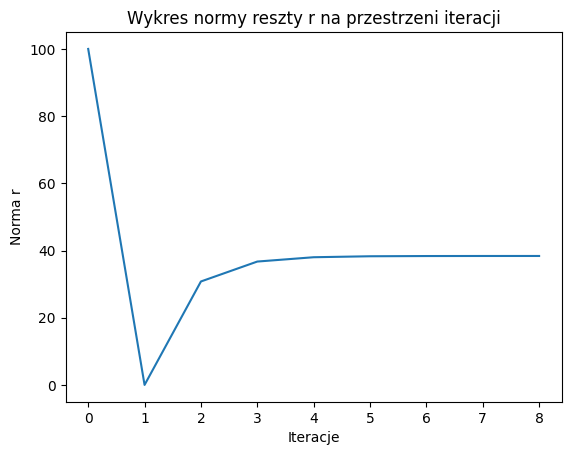

In [64]:
M, m = triple_diagonal(10)
A = [[4, -1, 1], [1, 6, 1], [-1, 2, 5]]
b = [4, 9, 2]
x, y = Gauss_Seidel_method(M, m)
print(x)
print(zbieznosc(M))
plt.plot(range(len(y)), y)
plt.title("Wykres normy reszty r na przestrzeni iteracji")
plt.xlabel("Iteracje")
plt.ylabel("Norma r")

Zadanie 3

In [59]:
print(solve(M, m))

[-7.73480663e+00 -2.07182320e+00 -5.52486188e-01 -1.38121547e-01
  7.43707090e-18  1.38121547e-01  5.52486188e-01  2.07182320e+00
  7.73480663e+00  2.88674033e+01]


Zadanie 4

In [60]:
def matrix_ex4():
    """Create a matrix B in R 20x20 that fits exercise 4 criteria"""
    B = [[0 for _ in range(20)] for _ in range(20)]
    diagonal = np.linspace(0.025, 0.5, 20)

    for i in range(len(B)-1):
        B[i][i] = diagonal[i]
        B[i][i+1] = 5
        
    B[-1][-1] = diagonal[-1]

    return B

In [61]:
B = matrix_ex4()
print(B)

[[0.025, 5, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0.05, 5, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0.075, 5, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0.1, 5, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0.125, 5, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0.15, 5, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0.175, 5, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0.19999999999999998, 5, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0.22499999999999998, 5, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0.24999999999999997, 5, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0.27499999999999997, 5, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0.3, 5, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0.325, 5, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0.35, 5, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0

Najmniejsze k spełniające warunek to: 86
[5.120028076094895, 26.21488375322905, 134.14732996924886, 685.7111667783898, 3499.4512221789623, 17821.15780784744, 90515.75233348168, 458278.1600684463, 2311501.129104684, 11607157.619700855, 57979284.278519936, 287800015.3516327, 1417711531.3721673, 6917193640.948411, 33332426564.004158, 157900410943.68704, 729295738747.7458, 3229516893003.308, 13128419579254.04, 40163327998699.87, 90961302479385.38, 161846452990474.6, 238997188980464.66, 304956673805362.6, 346149675192007.75, 357064219308292.4, 340154203581396.06, 303004053575048.6, 254869641773650.94, 204032806666852.12, 156451210458047.2, 115519789750439.86, 82500534221895.8, 57201249487706.04, 38626733855734.25, 25473828743859.55, 16445752557041.398, 10415086002714.43, 6481959386595.86, 3970769963542.495, 2397611392173.0103, 1428764871996.984, 841209266686.5422, 489825219335.381, 282332110523.3388, 161217066156.25546, 91265998123.33704, 51255448167.92932, 28573501743.770393, 15820319530.2

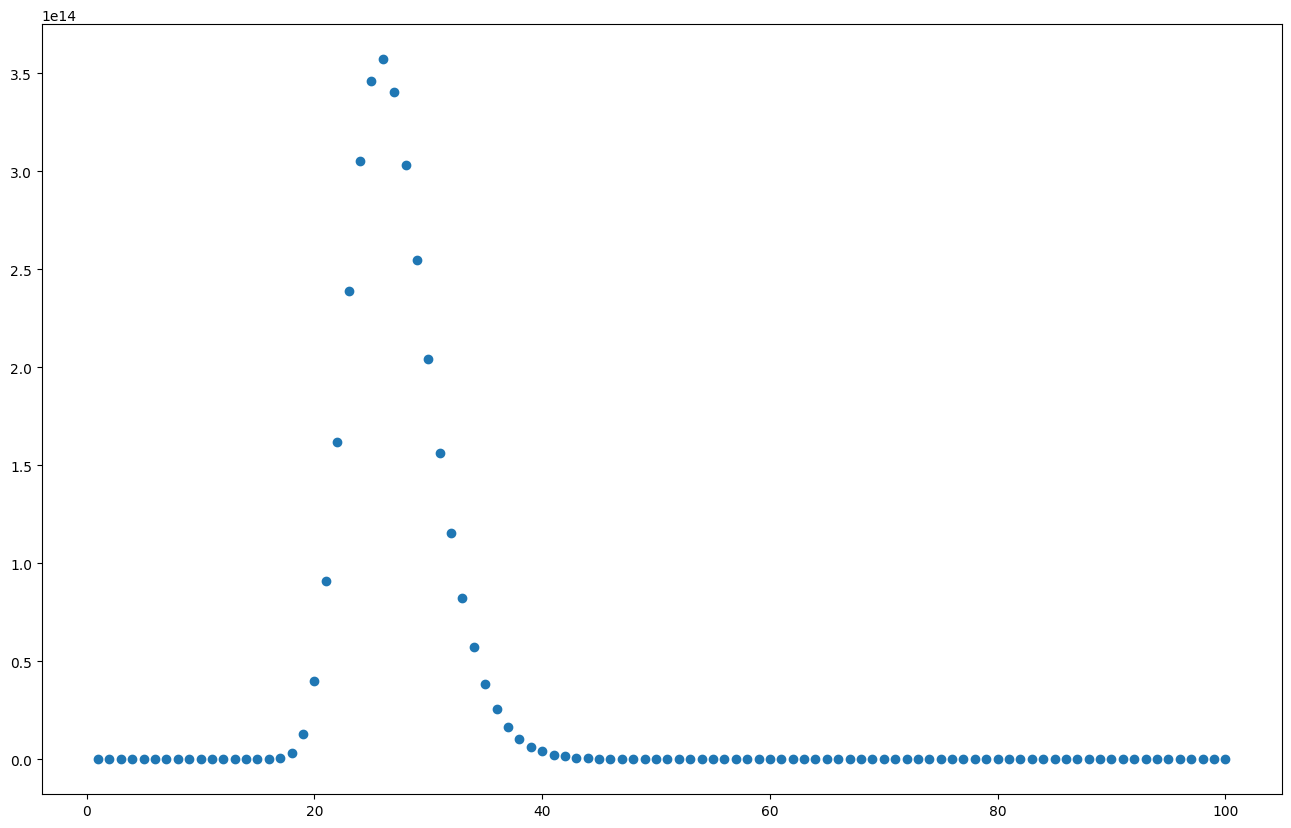

In [62]:
X = [np.ones(20)]
nk = []
jednorazowka = 0
for i in range(100):
    X.append(B @ X[i])
    nk.append(np.linalg.norm(X[i+1]) / np.linalg.norm(X[0]))
    if np.linalg.norm(X[i+1]) < np.linalg.norm(X[0]) and jednorazowka == 0:
        print(f"Najmniejsze k spełniające warunek to: {i+1}")
        jednorazowka += 1

X = X[1:]
plt.figure(figsize=(16, 10))
plt.scatter(range(1, 101), nk)
print(nk)